In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import os
import lightgbm as lgb

In [2]:
# 정제와 분석이 완료된 8.5년치 마스터 데이터셋을 불러오기

file_path = r"C:\Quant\merged_data.parquet"

merged = pd.read_parquet(file_path)

# 데이터 규모 및 정제 상태 확인
print(f"데이터 규모: {len(merged):,} 행")

데이터 규모: 32,951,194 행


In [3]:
merged.head(2)

,market,timeframe,timestamp_utc,timestamp_kst,open_u,high_u,low_u,close_u,volume_u,value,symbol,open_time,open_b,high_b,low_b,close_b,volume_b,taker_buy_base_volume,open_time_kst
0,KRW-BTC,minutes/1,2026-02-26 05:13:00,2026-02-26 14:13:00,98333000.0,98410000.0,98318000.0,98410000.0,2.894298,2.846193e+08,BTCUSDT,2026-02-26 05:13:00+00:00,68297.242188,68309.617188,68297.226562,68309.601562,2.58417,1.21303,2026-02-26 14:13:00
1,KRW-BTC,minutes/1,2026-02-26 05:14:00,2026-02-26 14:14:00,98410000.0,98447000.0,98400000.0,98411000.0,0.781258,7.688261e+07,BTCUSDT,2026-02-26 05:14:00+00:00,68309.601562,68322.656250,68301.570312,68301.570312,4.54242,0.74277,2026-02-26 14:14:00


In [4]:
merged.columns

Index(['market', 'timeframe', 'timestamp_utc', 'timestamp_kst', 'open_u',
       'high_u', 'low_u', 'close_u', 'volume_u', 'value', 'symbol',
       'open_time', 'open_b', 'high_b', 'low_b', 'close_b', 'volume_b',
       'taker_buy_base_volume', 'open_time_kst'],
      dtype='object')

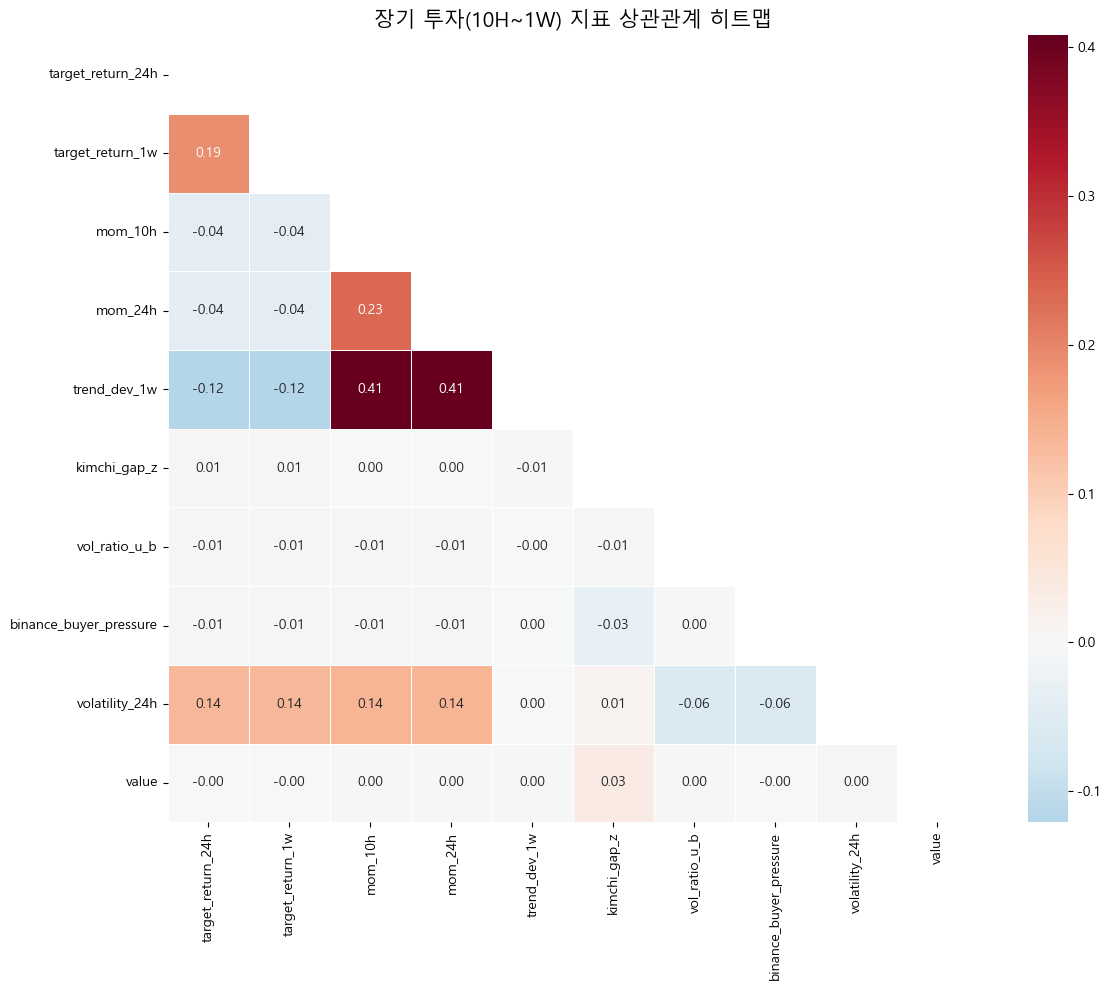


=== 미래 24시간 수익률(target_return_24h)과 높은 상관관계를 가진 지표 ===
volatility_24h            0.136770
kimchi_gap_z              0.006850
value                    -0.000321
vol_ratio_u_b            -0.008079
binance_buyer_pressure   -0.008225
mom_24h                  -0.043663
mom_10h                  -0.043684
trend_dev_1w             -0.120834
Name: target_return_24h, dtype: float64


In [ ]:
### 1. 선형관계 분석


plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

def analyze_long_term_correlations(df_input):
    # 원본 데이터 보존을 위해 복사
    df = df_input.copy()
    
    # 1. 시계열 정렬 (필수)
    if 'timestamp_kst' in df.columns:
        df['timestamp_kst'] = pd.to_datetime(df['timestamp_kst'])
        df = df.sort_values('timestamp_kst').reset_index(drop=True)
    
    # ---------------------------------------------------------
    # 2. 윈도우 설정 (1분봉 데이터 기준)
    # ---------------------------------------------------------
    # 장기 투자를 위한 시간 단위 상수 정의
    M_10H = 60 * 10       # 10시간 (600분)
    M_24H = 60 * 24       # 1일 (1440분)
    M_1W  = 60 * 24 * 7   # 1주일 (10080분)

    # ---------------------------------------------------------
    # 3. Feature Engineering (파생변수 생성)
    # ---------------------------------------------------------

    # (1) 목표 변수 (Target): 미래 수익률
    # 장기 투자이므로 '다음날(24시간 후)' 또는 '다음주(1주일 후)' 가격이 올랐는지가 중요
    df['target_return_24h'] = df['close_u'].shift(-M_24H) / df['close_u'] - 1
    df['target_return_1w'] = df['close_u'].shift(-M_1W) / df['close_u'] - 1

    # (2) 추세 지표 (Trend): 이동평균 이격도
    # 문법 오류 수정됨: 변수명에 공백 제거 (ma_1_week)
    ma_24h = df['close_u'].rolling(window=M_24H).mean()
    ma_1_week = df['close_u'].rolling(window=M_1W).mean()
    
    # 현재 가격이 장기 이평선 대비 어디에 있는가? (추세 판단)
    df['trend_dev_24h'] = (df['close_u'] - ma_24h) / ma_24h
    df['trend_dev_1w'] = (df['close_u'] - ma_1_week) / ma_1_week

    # (3) 모멘텀 지표 (Momentum): 과거 수익률
    # 최근 10시간, 24시간 동안 얼마나 올랐는가
    df['mom_10h'] = df['close_u'].pct_change(M_10H)
    df['mom_24h'] = df['close_u'].pct_change(M_24H)

    # (4) 김치 프리미엄 (Kimchi Premium Proxy)
    # 환율 정보가 없으므로 비율 자체를 지표로 사용 (Gap Ratio)
    # 이 지표의 절대값보다 이동평균(추세) 대비 현재 괴리율이 중요할 수 있음
    df['kimchi_gap'] = df['close_u'] / df['close_b']
    # 김치 프리미엄의 1주일 평균 대비 현재 수준 (김프가 급격히 끼었는지 빠졌는지)
    df['kimchi_gap_z'] = (df['kimchi_gap'] - df['kimchi_gap'].rolling(M_1W).mean()) / df['kimchi_gap'].rolling(M_1W).std()

    # (5) 수급 지표 (Volume & Sentiment)
    # 거래량은 노이즈가 심하므로 1시간(60분) 이동평균을 내서 비율 계산
    vol_u_smooth = df['volume_u'].rolling(60).sum()
    vol_b_smooth = df['volume_b'].rolling(60).sum()
    taker_smooth = df['taker_buy_base_volume'].rolling(60).sum()

    # 업비트 vs 바이낸스 거래량 비율 (업비트 과열 여부)
    df['vol_ratio_u_b'] = vol_u_smooth / vol_b_smooth
    
    # 바이낸스 매수 압력 (Taker Buy Ratio)
    # 1시간 동안의 바이낸스 총 거래량 중 공격적 매수(Taker) 비율
    df['binance_buyer_pressure'] = taker_smooth / vol_b_smooth

    # (6) 변동성 (Volatility)
    # 최근 24시간 동안의 가격 변화 표준편차
    df['volatility_24h'] = df['close_u'].pct_change().rolling(M_24H).std()

    # ---------------------------------------------------------
    # 4. 상관관계 분석
    # ---------------------------------------------------------
    # 분석에 사용할 컬럼 정의 (NaN 제거 후 계산)
    features = [
        'target_return_24h',       # [Target] 미래 24시간 수익률
        'target_return_1w',        # [Target] 미래 1주일 수익률
        'mom_10h',                 # 10시간 모멘텀
        'mom_24h',                 # 24시간 모멘텀
        'trend_dev_1w',            # 1주 이평선 이격도
        'kimchi_gap_z',            # 김치 프리미엄 과열도
        'vol_ratio_u_b',           # 거래소간 거래량 비율
        'binance_buyer_pressure',  # 바이낸스 매수 심리
        'volatility_24h',          # 변동성
        'value'                    # 거래 대금
    ]
    
    corr_df = df[features].dropna()
    corr_matrix = corr_df.corr(method='pearson')

    # ---------------------------------------------------------
    # 5. 결과 시각화
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 상삼각행렬 마스킹 (보기 편하게)
    
    sns.heatmap(corr_matrix, 
                annot=True, 
                fmt='.2f', 
                cmap='RdBu_r', # 빨간색이 양의 상관관계, 파란색이 음의 상관관계
                center=0,
                mask=mask,
                linewidths=0.5)
    
    plt.title('장기 투자(10H~1W) 지표 상관관계 히트맵', fontsize=15)
    plt.tight_layout()
    plt.show()

    return corr_matrix

# 실행 (이미 로드된 merged_df 사용)
correlation_result = analyze_long_term_correlations(merged)

# 가장 중요한 '미래 수익률'과의 상관관계 출력
print("\n=== 미래 24시간 수익률(target_return_24h)과 높은 상관관계를 가진 지표 ===")
print(correlation_result['target_return_24h'].drop(['target_return_24h', 'target_return_1w']).sort_values(ascending=False))



=== 지표별 중요도 비교 (절대값 기준) ===
                Pearson (Linear)  Mutual Info (Non-linear)
trend_dev_1w            0.120827                  1.264358
BB_Pct                  0.115371                  0.652868
mom_24h                 0.043685                  0.633010
RSI                     0.084280                  0.618235
value                   0.000320                  0.086480
volatility_24h          0.136646                  0.045154


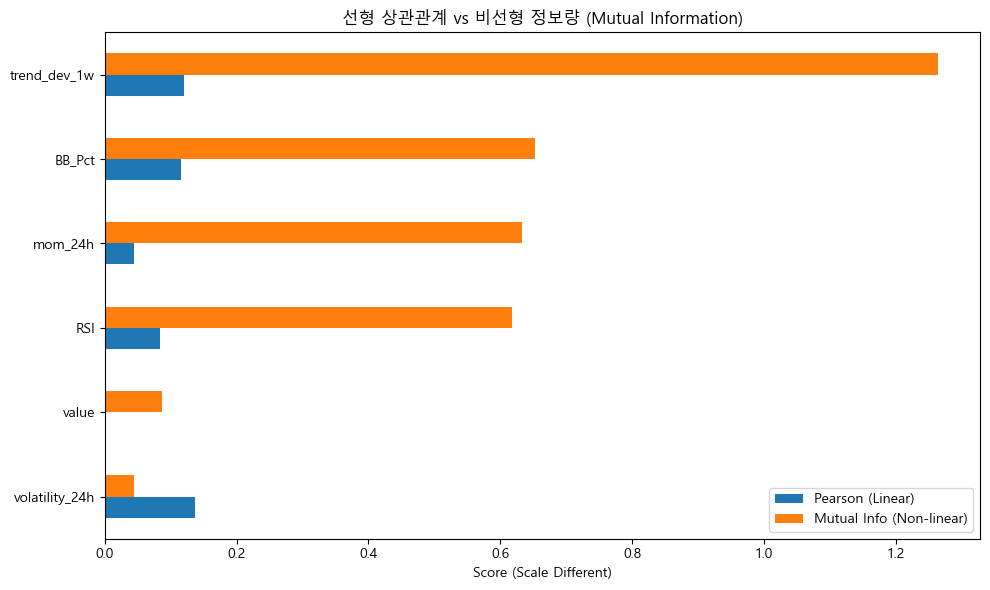

In [9]:
from sklearn.feature_selection import mutual_info_regression

### 2. 비선형관계 분석


# ---------------------------------------------------------
# 1. 기술적 지표 추가 함수 (RSI, Bollinger Bands)
# ---------------------------------------------------------
def add_technical_indicators(df):
    data = df.copy()
    
    # RSI (상대 강도 지수) - 14일 기준
    delta = data['close_u'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14*24*60).mean() # 분봉 데이터라 window가 큼
    loss = (-delta.where(delta < 0, 0)).rolling(window=14*24*60).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # Bollinger Bands (볼린저 밴드) - 20일 기준
    window_bb = 20 * 24 * 60
    sma = data['close_u'].rolling(window=window_bb).mean()
    std = data['close_u'].rolling(window=window_bb).std()
    data['BB_Upper'] = sma + (2 * std)
    data['BB_Lower'] = sma - (2 * std)
    
    # %B (밴드 내 위치): 1보다 크면 과매수, 0보다 작으면 과매도
    data['BB_Pct'] = (data['close_u'] - data['BB_Lower']) / (data['BB_Upper'] - data['BB_Lower'])
    
    return data

# ---------------------------------------------------------
# 2. 비선형 상관관계 분석 (Mutual Information)
# ---------------------------------------------------------
def analyze_nonlinear_correlations(df_input):
    # 전처리 및 지표 추가
    df = df_input.copy()
    if 'timestamp_kst' in df.columns:
        df = df.sort_values('timestamp_kst').reset_index(drop=True)
        
    df = add_technical_indicators(df)
    
    # 기존 파생변수 생성 (이전 로직 재사용)
    M_24H = 60 * 24
    M_1W  = 60 * 24 * 7
    
    # Target
    df['target_return_24h'] = df['close_u'].shift(-M_24H) / df['close_u'] - 1
    
    # Features
    df['volatility_24h'] = df['close_u'].pct_change().rolling(M_24H).std()
    ma_1_week = df['close_u'].rolling(window=M_1W).mean()
    df['trend_dev_1w'] = (df['close_u'] - ma_1_week) / ma_1_week
    df['mom_24h'] = df['close_u'].pct_change(M_24H)
    
    # 분석할 Feature 목록
    features = [
        'volatility_24h', 'trend_dev_1w', 'mom_24h', 
        'RSI', 'BB_Pct', 'value'
    ]
    
    # 결측치 제거
    analysis_df = df[features + ['target_return_24h']].dropna()
    
    # (A) 피어슨 상관계수 (선형)
    linear_corr = analysis_df.corr()['target_return_24h'].drop('target_return_24h')
    
    # (B) 상호 의존성 정보 (비선형 포함)
    # 데이터가 너무 많으면 시간이 오래 걸리므로 최근 10,000개 샘플링 혹은 전체 사용
    sample_df = analysis_df.tail(10000) 
    mi_scores = mutual_info_regression(sample_df[features], sample_df['target_return_24h'])
    mi_series = pd.Series(mi_scores, index=features)
    
    # ---------------------------------------------------------
    # 3. 결과 비교 시각화
    # ---------------------------------------------------------
    results = pd.DataFrame({
        'Pearson (Linear)': linear_corr.abs(), # 절대값으로 비교
        'Mutual Info (Non-linear)': mi_series
    })
    
    # 스케일이 다르므로 정규화하여 패턴 비교
    results_norm = (results - results.min()) / (results.max() - results.min())
    
    print("\n=== 지표별 중요도 비교 (절대값 기준) ===")
    print(results.sort_values(by='Mutual Info (Non-linear)', ascending=False))

    results.sort_values(by='Mutual Info (Non-linear)', ascending=True).plot(kind='barh', figsize=(10, 6))
    plt.title('선형 상관관계 vs 비선형 정보량 (Mutual Information)')
    plt.xlabel('Score (Scale Different)')
    plt.tight_layout()
    plt.show()

analyze_nonlinear_correlations(merged)


사용 장치: cpu
1. 데이터 전처리 중...
학습 데이터 타겟 분포:
target
0.0    0.502918
1.0    0.497082
Name: proportion, dtype: float64

학습 데이터: 15424개, 테스트 데이터: 2529개

2. PyTorch 모델 학습 시작 (Early Stopping 적용)...


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 5/100, Loss: 0.6932 (Patience: 0/15)
Epoch 10/100, Loss: 0.6932 (Patience: 5/15)
Epoch 15/100, Loss: 0.6931 (Patience: 1/15)
Epoch 20/100, Loss: 0.6931 (Patience: 0/15)
Epoch 25/100, Loss: 0.6931 (Patience: 3/15)
Epoch 30/100, Loss: 0.6931 (Patience: 1/15)
Epoch 35/100, Loss: 0.6930 (Patience: 1/15)
Epoch 40/100, Loss: 0.6929 (Patience: 0/15)
Epoch 45/100, Loss: 0.6929 (Patience: 3/15)
Epoch 50/100, Loss: 0.6928 (Patience: 1/15)
Epoch 55/100, Loss: 0.6927 (Patience: 0/15)
Epoch 60/100, Loss: 0.6928 (Patience: 5/15)
Epoch 65/100, Loss: 0.6926 (Patience: 2/15)
Epoch 70/100, Loss: 0.6925 (Patience: 1/15)
Epoch 75/100, Loss: 0.6923 (Patience: 3/15)
Epoch 80/100, Loss: 0.6918 (Patience: 0/15)
Epoch 85/100, Loss: 0.6916 (Patience: 0/15)
Epoch 90/100, Loss: 0.6914 (Patience: 1/15)
Epoch 95/100, Loss: 0.6921 (Patience: 6/15)
Epoch 100/100, Loss: 0.6924 (Patience: 11/15)

3. 2025년 데이터 백테스팅 시작

 [2025년 PyTorch 시뮬레이션 결과]
 최종 자본: 10,434,933,511,731,003,001,191,559,871,419,261,006,680,659,561

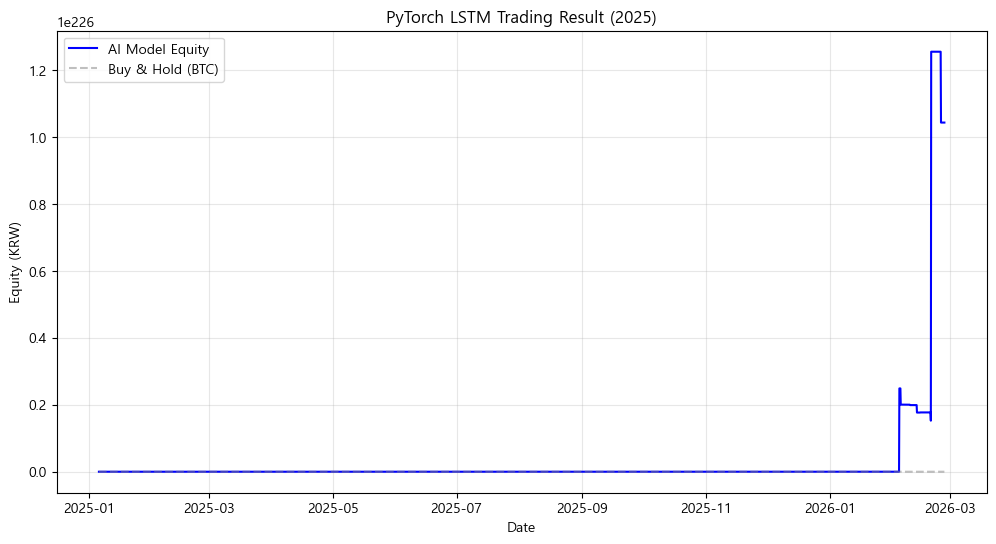

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# 2. 시퀀스 생성 함수
def create_sequences(X, y=None, time_steps=60):
    Xs, ys = [], []
    if y is None:
        for i in range(len(X) - time_steps):
            Xs.append(X[i:(i + time_steps)])
        return np.array(Xs), None
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# 3. 데이터 전처리
def preprocess_features(df_input):
    df = df_input.copy()
    if 'timestamp_kst' in df.columns:
        df['timestamp_kst'] = pd.to_datetime(df['timestamp_kst'])
        df = df.sort_values('timestamp_kst').set_index('timestamp_kst')
    
    # [수정] 'H' -> 'h'로 변경
    agg_dict = {
        'open_u': 'first', 'high_u': 'max', 'low_u': 'min', 'close_u': 'last',
        'volume_u': 'sum', 'value': 'sum'
    }
    available_cols = {k: v for k, v in agg_dict.items() if k in df.columns}
    df_resampled = df.resample('4h').agg(available_cols).dropna()

    # 파생 변수
    df_resampled['volatility'] = df_resampled['close_u'].pct_change().rolling(24).std()
    ma_week = df_resampled['close_u'].rolling(window=42).mean()
    df_resampled['trend_dev'] = (df_resampled['close_u'] - ma_week) / ma_week
    delta = df_resampled['close_u'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_resampled['rsi'] = 100 - (100 / (1 + rs))
    window_bb = 20
    sma = df_resampled['close_u'].rolling(window=window_bb).mean()
    std = df_resampled['close_u'].rolling(window=window_bb).std()
    upper = sma + (2 * std)
    lower = sma - (2 * std)
    df_resampled['bb_pct'] = (df_resampled['close_u'] - lower) / (upper - lower)
    df_resampled['log_value'] = np.log1p(df_resampled['value'])
    df_resampled['target'] = (df_resampled['close_u'].shift(-1) > df_resampled['close_u']).astype(float)
    df_resampled['next_return'] = df_resampled['close_u'].shift(-1) / df_resampled['close_u'] - 1

    return df_resampled.dropna()

# 4. LSTM 모델 정의
class LSTMTrader(nn.Module):
    # [수정] 모델 구조를 약간 단순화 (num_layers=1)
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, output_dim=1):
        super(LSTMTrader, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# 5. 실행 및 백테스팅 함수
def run_pytorch_trading(merged_df):
    print("1. 데이터 전처리 중...")
    data = preprocess_features(merged_df)
    
    train_data = data[data.index < '2025-01-01']
    test_data = data[data.index >= '2025-01-01']
    
    # [추가] 타겟 데이터 분포 확인
    target_dist = train_data['target'].value_counts(normalize=True)
    print(f"학습 데이터 타겟 분포:\n{target_dist}\n")
    
    print(f"학습 데이터: {len(train_data)}개, 테스트 데이터: {len(test_data)}개")
    
    feature_cols = ['close_u', 'volatility', 'trend_dev', 'rsi', 'bb_pct', 'log_value']
    
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(train_data[feature_cols])
    
    time_steps = 30
    lookback_data = train_data[feature_cols].iloc[-time_steps:]
    test_data_with_lookback = pd.concat([lookback_data, test_data[feature_cols]])
    X_test_scaled = scaler.transform(test_data_with_lookback)
    
    X_train_np, y_train_np = create_sequences(X_train_scaled, train_data['target'].values, time_steps)
    X_test_np, _ = create_sequences(X_test_scaled, y=None, time_steps=time_steps)
    
    X_train_t = torch.tensor(X_train_np, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1).to(device)
    X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # [수정] 모델 구조 단순화 및 학습률 조정
    model = LSTMTrader(input_dim=len(feature_cols)).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005) # 학습률을 약간 낮춤

    print("\n2. PyTorch 모델 학습 시작 (Early Stopping 적용)...")
    epochs = 100
    patience = 15 # Patience를 약간 늘림
    best_loss = float('inf')
    counter = 0
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            counter = 0
        else:
            counter += 1
            
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f} (Patience: {counter}/{patience})")
            
        if counter >= patience:
            print(f"Early Stopping 발동! Epoch {epoch+1}에서 학습 종료.")
            break
            
    print("\n3. 2025년 데이터 백테스팅 시작")
    model.eval()
    with torch.no_grad():
        predictions = model(X_test_t).cpu().numpy().flatten()
    
    actual_returns = test_data['next_return'].values[time_steps:]

    initial_balance = 10_000_000
    balance = initial_balance
    balance_history = [initial_balance]
    buy_threshold = 0.55
    
    trade_count = 0
    win_count = 0
    
    for i in range(len(predictions)):
        if i >= len(actual_returns): break
        prob = predictions[i]
        actual_ret = actual_returns[i]
        
        if prob > buy_threshold:
            kelly_fraction = (prob * 2) - 1
            position_size = min(kelly_fraction, 0.5)
            invest_amount = balance * position_size
            profit = invest_amount * actual_ret
            balance += profit
            trade_count += 1
            if profit > 0: win_count += 1
        balance_history.append(balance)
        
    final_return = (balance / initial_balance - 1) * 100
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0

    print("\n" + "="*40)
    print(f" [2025년 PyTorch 시뮬레이션 결과]")
    print(f" 최종 자본: {balance:,.0f} KRW")
    print(f" 수익률: {final_return:.2f}%")
    print(f" 거래 횟수: {trade_count}회")
    print(f" 승률: {win_rate:.2f}%")
    print("="*40)
    
    # [수정] 시각화 부분 인덱스 맞추기
    # balance_history는 N+1개, 예측은 N개이므로, X축도 N+1개로 맞춰줌
    plot_index = test_data.index[time_steps-1:time_steps-1+len(balance_history)]

    plt.figure(figsize=(12, 6))
    plt.plot(plot_index, balance_history, label='AI Model Equity', color='blue')
    
    benchmark_data = test_data.iloc[time_steps-1:]
    benchmark = (benchmark_data['close_u'] / benchmark_data['close_u'].iloc[0]) * initial_balance
    plt.plot(benchmark.index, benchmark, label='Buy & Hold (BTC)', color='gray', linestyle='--', alpha=0.5)
    
    plt.title('PyTorch LSTM Trading Result (2025)')
    plt.xlabel('Date')
    plt.ylabel('Equity (KRW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
if 'merged' in locals():
    run_pytorch_trading(merged)
else:
    print("Error: 'merged' 데이터프레임 필요.")